# Detailed Retriever Evaluation Pipeline

**Input:**
- `data/processed/books.csv` (or clean books CSV configured in `.env`)
- `data/eval/qrels.json` (ground-truth relevance judgments)
- All model indexes (`models/`, `data/chroma_db/`)

**Goal:**
Evaluate all five retriever pipelines across standard Information Retrieval metrics, visualize performance, and inspect sample queries with book title and description mappings instead of raw ISBNs.

**Evaluated Retrievers:**
1. TF-IDF
2. BM25
3. Dense (ChromaDB + BGE-small)
4. Hybrid RRF (BM25 + Dense)
5. Reranking (Dense + Cross-Encoder / Jina API)

## 0. Setup and Configuration

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import warnings
warnings.filterwarnings('ignore')

from src.config.settings import get_settings
from src.pipelines.evaluate_retrievers import load_dataframe, load_qrels
from src.retrieval.tfidf_retriever import TFIDFRetriever
from src.retrieval.bm25_retriever import BM25Retriever
from src.retrieval.dense_retriever import DenseRetriever
from src.retrieval.hybrid_rrf_retriever import HybridRRFRetriever
from src.retrieval.rerank_retriever import RerankRetriever
from src.evaluation.metrics import precision_at_k, recall_at_k, mrr, ndcg_at_k, map_score

# Matplotlib settings for rich aesthetics
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F9F9F9',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

MODEL_COLORS = {
    'TF-IDF'   : '#6B8CBA',
    'BM25'     : '#F4A261',
    'Dense'    : '#2A9D8F',
    'Hybrid'   : '#E76F51',
    'Reranking': '#8338EC',
}

# 1. Load settings and books dataset
settings = get_settings()
df = load_dataframe(settings)
print(f"Loaded books dataset: {len(df):,} books")

# 2. Load qrels
qrels = load_qrels(settings.eval_output_path / "qrels.json")
print(f"Loaded ground-truth qrels: {len(qrels)} queries")

Loaded books dataset: 11,606 books
Loaded ground-truth qrels: 262 queries


In [2]:
# 3. Load all 5 retrievers
print("Loading retrievers...")
tfidf = TFIDFRetriever.load(
    model_path=Path(settings.tfidf_model_path),
    matrix_path=Path(settings.tfidf_matrix_path),
    df=df,
)
print("  TF-IDF loaded [OK]")

bm25 = BM25Retriever.load(
    index_path=Path(settings.bm25_index_path),
    df=df,
)
print("  BM25 loaded [OK]")

dense = DenseRetriever.load(
    chroma_path=Path(settings.chroma_path),
    embedding_model=settings.embedding_model,
    collection_name=settings.chroma_collection_name,
)
print("  Dense (ChromaDB) loaded [OK]")

hybrid = HybridRRFRetriever(
    bm25_retriever=bm25,
    dense_retriever=dense,
    candidate_pool=settings.hybrid_candidate_pool,
    rrf_k=settings.rrf_k,
)
print("  Hybrid RRF loaded [OK]")

rerank = RerankRetriever(
    dense_retriever=dense,
    rerank_model=settings.jina_rerank_model if settings.rerank_use_api else settings.rerank_model,
    candidate_pool=settings.rerank_candidate_pool,
    use_api=settings.rerank_use_api,
    jina_api_key=settings.jina_api_key,
    rerank_workers=settings.rerank_workers,
)
print("  Reranking loaded [OK]")

retrievers = {
    'tfidf': tfidf,
    'bm25': bm25,
    'dense': dense,
    'hybrid_rrf': hybrid,
    'rerank': rerank
}

Loading retrievers...
  TF-IDF loaded [OK]
  BM25 loaded [OK]
  Dense (ChromaDB) loaded [OK]
  Hybrid RRF loaded [OK]
  Reranking loaded [OK]


## 1. Caching Search Results
To avoid re-running all queries in every single metric cell, we will cache the search results and timing (latency) in memory first.

In [3]:
print(f"Running retrieval on {len(qrels)} queries...")
retrieved_results = {name: [] for name in retrievers.keys()}
latencies = {name: [] for name in retrievers.keys()}

for i, qrel in enumerate(qrels):
    if (i + 1) % 10 == 0 or i == 0 or i == len(qrels) - 1:
        print(f"  Processing query {i + 1}/{len(qrels)}: '{qrel.query[:40]}...'")
    for name, retriever in retrievers.items():
        t_start = time.perf_counter()
        results = retriever.search(qrel.query, top_k=10)
        elapsed_ms = (time.perf_counter() - t_start) * 1000
        
        retrieved_results[name].append([res.isbn13 for res in results])
        latencies[name].append(elapsed_ms)

print("\nRetrieval caching finished! Ready for metric calculations.")

Running retrieval on 262 queries...
  Processing query 1/262: 'vegetarian recipes...'


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1841.11it/s]


  Processing query 10/262: 'medical nutrition therapy...'
  Processing query 20/262: 'designing spaces for human comfort...'
  Processing query 30/262: 'novels about overcoming challenges in sp...'
  Processing query 40/262: 'coming of age stories in classic literat...'
  Processing query 50/262: 'books discussing the ethics of wildness...'
  Processing query 60/262: 'novels exploring the consequences of sec...'
  Processing query 70/262: 'explorations of psychological reality an...'
  Processing query 80/262: 'historical accounts of Jesuit missions...'
  Processing query 90/262: 'classic romantic novels...'
  Processing query 100/262: 'scientific biography collections...'
  Processing query 110/262: 'books on nationalism and justice...'
  Processing query 120/262: 'historical romance novels...'
  Processing query 130/262: 'villain academy stories...'
  Processing query 140/262: 'space marine novels...'
  Processing query 150/262: 'science fiction anthologies...'
  Processing query 160

## 2. Metric Computation Cells
In the following cells, we calculate the average score of each metric for all retrievers.

### Metric: Precision@5

In [4]:
p5_scores = {}
for name in retrievers.keys():
    scores = [precision_at_k(ret, set(qrel.relevant_isbns), k=5) 
              for ret, qrel in zip(retrieved_results[name], qrels)]
    p5_scores[name] = np.mean(scores)

print("=" * 40)
print(f"Mean Precision@5 (n={len(qrels)} queries)")
print("=" * 40)
for name, val in p5_scores.items():
    print(f"{name:<12}: {val:.4f}")
print("=" * 40)

Mean Precision@5 (n=262 queries)
tfidf       : 0.1046
bm25        : 0.1290
dense       : 0.3931
hybrid_rrf  : 0.2649
rerank      : 0.5107


### Metric: Precision@10

In [5]:
p10_scores = {}
for name in retrievers.keys():
    scores = [precision_at_k(ret, set(qrel.relevant_isbns), k=10) 
              for ret, qrel in zip(retrieved_results[name], qrels)]
    p10_scores[name] = np.mean(scores)

print("=" * 40)
print(f"Mean Precision@10 (n={len(qrels)} queries)")
print("=" * 40)
for name, val in p10_scores.items():
    print(f"{name:<12}: {val:.4f}")
print("=" * 40)

Mean Precision@10 (n=262 queries)
tfidf       : 0.0725
bm25        : 0.0935
dense       : 0.3294
hybrid_rrf  : 0.2427
rerank      : 0.4229


### Metric: Recall@5

In [6]:
r5_scores = {}
for name in retrievers.keys():
    scores = [recall_at_k(ret, set(qrel.relevant_isbns), k=5) 
              for ret, qrel in zip(retrieved_results[name], qrels)]
    r5_scores[name] = np.mean(scores)

print("=" * 40)
print(f"Mean Recall@5 (n={len(qrels)} queries)")
print("=" * 40)
for name, val in r5_scores.items():
    print(f"{name:<12}: {val:.4f}")
print("=" * 40)

Mean Recall@5 (n=262 queries)
tfidf       : 0.1049
bm25        : 0.1493
dense       : 0.3822
hybrid_rrf  : 0.2761
rerank      : 0.5100


### Metric: Recall@10

In [7]:
r10_scores = {}
for name in retrievers.keys():
    scores = [recall_at_k(ret, set(qrel.relevant_isbns), k=10) 
              for ret, qrel in zip(retrieved_results[name], qrels)]
    r10_scores[name] = np.mean(scores)

print("=" * 40)
print(f"Mean Recall@10 (n={len(qrels)} queries)")
print("=" * 40)
for name, val in r10_scores.items():
    print(f"{name:<12}: {val:.4f}")
print("=" * 40)

Mean Recall@10 (n=262 queries)
tfidf       : 0.1395
bm25        : 0.1952
dense       : 0.6178
hybrid_rrf  : 0.4601
rerank      : 0.7795


### Metric: Mean Reciprocal Rank (MRR)

In [8]:
mrr_scores = {}
for name in retrievers.keys():
    scores = [mrr(ret, set(qrel.relevant_isbns)) 
              for ret, qrel in zip(retrieved_results[name], qrels)]
    mrr_scores[name] = np.mean(scores)

print("=" * 40)
print(f"Mean Reciprocal Rank (MRR) (n={len(qrels)} queries)")
print("=" * 40)
for name, val in mrr_scores.items():
    print(f"{name:<12}: {val:.4f}")
print("=" * 40)

Mean Reciprocal Rank (MRR) (n=262 queries)
tfidf       : 0.2671
bm25        : 0.3125
dense       : 0.6830
hybrid_rrf  : 0.4637
rerank      : 0.6855


### Metric: NDCG@10

In [9]:
ndcg_scores = {}
for name in retrievers.keys():
    scores = [ndcg_at_k(ret, set(qrel.relevant_isbns), k=10) 
              for ret, qrel in zip(retrieved_results[name], qrels)]
    ndcg_scores[name] = np.mean(scores)

print("=" * 40)
print(f"Mean NDCG@10 (n={len(qrels)} queries)")
print("=" * 40)
for name, val in ndcg_scores.items():
    print(f"{name:<12}: {val:.4f}")
print("=" * 40)

Mean NDCG@10 (n=262 queries)
tfidf       : 0.1448
bm25        : 0.1931
dense       : 0.5500
hybrid_rrf  : 0.3787
rerank      : 0.6670


### Metric: Mean Average Precision (MAP)

In [10]:
map_scores = {}
for name in retrievers.keys():
    scores = [map_score(ret, set(qrel.relevant_isbns)) 
              for ret, qrel in zip(retrieved_results[name], qrels)]
    map_scores[name] = np.mean(scores)

print("=" * 40)
print(f"Mean Average Precision (MAP) (n={len(qrels)} queries)")
print("=" * 40)
for name, val in map_scores.items():
    print(f"{name:<12}: {val:.4f}")
print("=" * 40)

Mean Average Precision (MAP) (n=262 queries)
tfidf       : 0.0940
bm25        : 0.1307
dense       : 0.3971
hybrid_rrf  : 0.2416
rerank      : 0.5283


## 3. Metrics Visualizations

Retriever      P@5     P@10      R@5     R@10      MRR  NDCG@10      MAP
   TF-IDF 0.104580 0.072519 0.104907 0.139477 0.267138 0.144801 0.093990
     BM25 0.129008 0.093511 0.149346 0.195197 0.312498 0.193081 0.130745
    Dense 0.393130 0.329389 0.382152 0.617848 0.682980 0.549955 0.397066
   Hybrid 0.264885 0.242748 0.276072 0.460055 0.463677 0.378713 0.241591
Reranking 0.510687 0.422901 0.510024 0.779517 0.685511 0.667036 0.528323


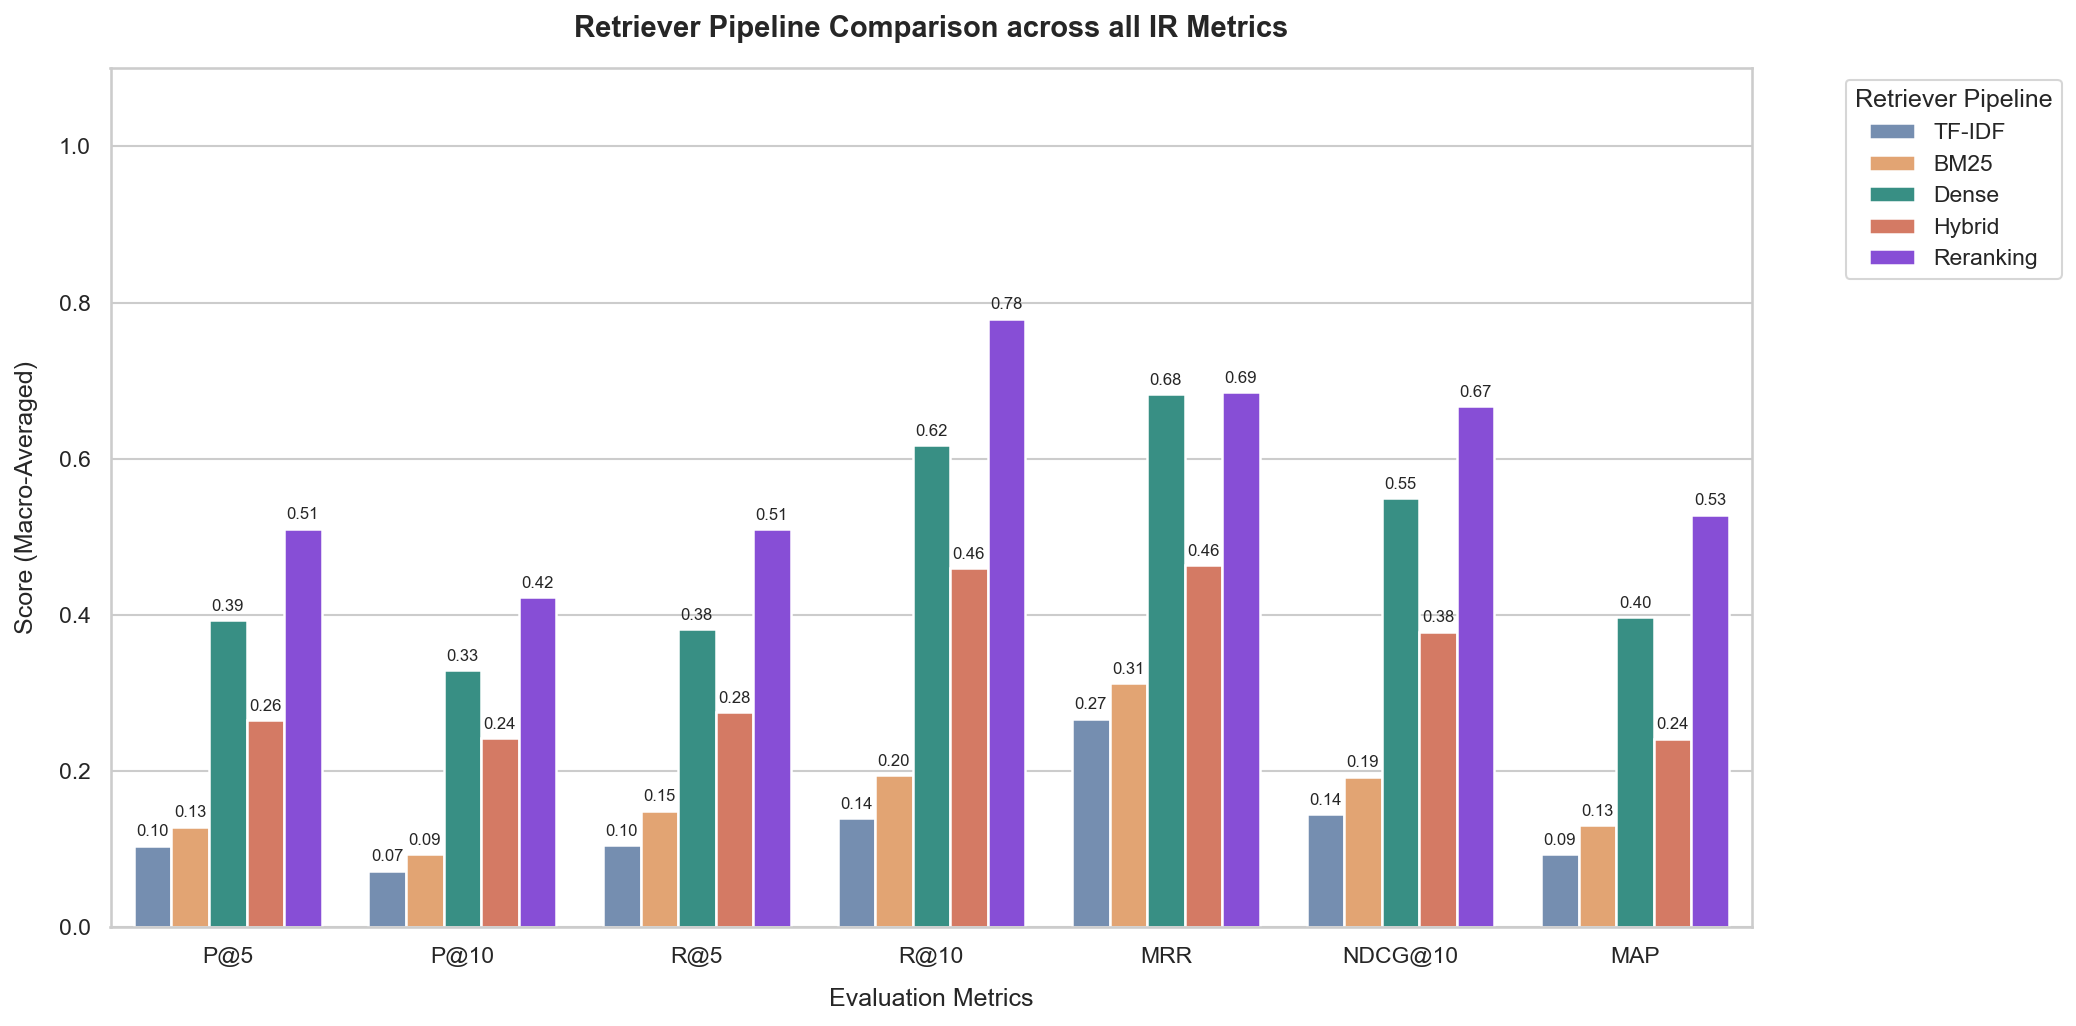

In [11]:
# Gather all metrics into a pandas DataFrame
metrics_summary = []
retriever_labels = {
    'tfidf': 'TF-IDF',
    'bm25': 'BM25',
    'dense': 'Dense',
    'hybrid_rrf': 'Hybrid',
    'rerank': 'Reranking'
}

for name in retrievers.keys():
    metrics_summary.append({
        'Retriever': retriever_labels[name],
        'P@5': p5_scores[name],
        'P@10': p10_scores[name],
        'R@5': r5_scores[name],
        'R@10': r10_scores[name],
        'MRR': mrr_scores[name],
        'NDCG@10': ndcg_scores[name],
        'MAP': map_scores[name]
    })

df_metrics = pd.DataFrame(metrics_summary)
print(df_metrics.to_string(index=False))

# Melt DataFrame for seaborn grouped barplot
df_melted = df_metrics.melt(id_vars='Retriever', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    data=df_melted,
    x='Metric',
    y='Score',
    hue='Retriever',
    palette=[MODEL_COLORS[retriever_labels[name]] for name in retrievers.keys()],
    edgecolor='white',
    linewidth=1.2
)

# Add scores on top of bars
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.2f}', 
                    xy=(p.get_x() + p.get_width() / 2, h),
                    xytext=(0, 3), 
                    textcoords='offset points', 
                    ha='center', va='bottom', fontsize=8)

plt.title('Retriever Pipeline Comparison across all IR Metrics', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Evaluation Metrics', fontsize=12, labelpad=10)
plt.ylabel('Score (Macro-Averaged)', fontsize=12, labelpad=10)
plt.ylim(0, 1.1)
plt.legend(title='Retriever Pipeline', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the figure
figures_dir = Path("reports/figures")
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "retriever_metrics_comparison.png", bbox_inches='tight', dpi=150)
plt.show()

## 4. Qualitative Analysis & Visual Mapping
Let's visualize the actual **book titles** and **descriptions** corresponding to the ground-truth relevant books and the retriever predictions.

In [12]:
# Helper to look up title and description from books DataFrame
def get_book_details(isbn: str) -> tuple[str, str]:
    matches = df[df['isbn13'] == str(isbn)]
    if not matches.empty:
        title = matches.iloc[0]['title']
        desc = matches.iloc[0]['description']
        return str(title), str(desc)
    return "Unknown Book", "No description available in dataset."

# Pick 3 interesting queries with non-empty ground truth
sample_queries = []
for q in qrels:
    if len(q.relevant_isbns) >= 2:
        sample_queries.append(q)
    if len(sample_queries) == 3:
        break

# Fallback in case there are not enough queries with >= 2 relevant books
if len(sample_queries) < 3:
    sample_queries = qrels[:3]

for idx, qrel in enumerate(sample_queries):
    print(f"\n{'='*95}")
    print(f"QUERY #{idx + 1}: \"{qrel.query}\"")
    print(f"{'='*95}")
    
    # 1. Ground Truth Details
    print("\n--- GROUND TRUTH RELEVANT BOOKS ---")
    for g_isbn in qrel.relevant_isbns:
        g_title, g_desc = get_book_details(g_isbn)
        print(f"  * ISBN: {g_isbn} | Title: {g_title}")
        print(f"    Description: {g_desc[:150]}\n{g_desc[150:300]}\n{g_desc[300:450]}\n{g_desc[450:600]}\n{g_desc[600:750]}\n{g_desc[750:900]}")
        print("-" * 70)
        
    # 2. Retriever Predictions Details
    print("\n--- RETRIEVER PREDICTIONS ---")
    for name, retriever in retrievers.items():
        print(f"\n[{retriever_labels[name]} Retriever]")
        # Find index of this query in cached results
        q_idx = qrels.index(qrel)
        pred_isbns = retrieved_results[name][q_idx][:5]  # Top 5
        
        for rank, p_isbn in enumerate(pred_isbns, start=1):
            p_title, p_desc = get_book_details(p_isbn)
            is_hit = p_isbn in qrel.relevant_isbns
            hit_str = "[HIT]" if is_hit else "[MISS]"
            print(f"    Rank {rank} | {hit_str} | ISBN: {p_isbn} | Title: {p_title}")
            print(f"    Description: {p_desc[:150]}\n{p_desc[150:300]}\n{p_desc[300:450]}\n{p_desc[450:600]}\n{p_desc[600:750]}\n{p_desc[750:900]}")


QUERY #1: "comprehensive nutrition textbooks for students"

--- GROUND TRUTH RELEVANT BOOKS ---
  * ISBN: 9780763758738 | Title: Discovering Nutrition
    Description: Discovering Nutrition, Third Edition is a student-friendly introduction to nutrition on a non-majors level. Coverage of material such as digestion, me
tabolism, chemistry, and life cycle nutrition is clearly written, accessible, and engaging to undergraduate students.




----------------------------------------------------------------------
  * ISBN: 9781264583379 | Title: Essentials of Clinical Nutrition in Healthcare
    Description: Proven methods for diagnosing and managing nutritional changes in patients with chronic diseases and conditions Essentials of Clinical Nutrition in He
althcare fills the well-recognized evidence-practice gap between the nutrition knowledge, skills, and attitudes needed for nutrition care and the nutr
ition education provided by medical schools. Focusing on nutrition and dietetics, it wal

## 5. Hybrid Evaluation with Weights 

Caching candidate search results for BM25 and Dense...
  Fetching candidates for query 1/262...
  Fetching candidates for query 50/262...
  Fetching candidates for query 100/262...
  Fetching candidates for query 150/262...
  Fetching candidates for query 200/262...
  Fetching candidates for query 250/262...
  Fetching candidates for query 262/262...

Evaluating weight combinations...
Weight Config             | P@5      | P@10     | R@5      | R@10     | MRR      | NDCG@10  | MAP     
BM25:0.8 / Dense:0.2      | 0.1840   | 0.1298    | 0.1957   | 0.2532    | 0.3824   | 0.2453     | 0.1626
BM25:0.7 / Dense:0.3      | 0.1863   | 0.1305    | 0.1971   | 0.2543    | 0.3789   | 0.2455     | 0.1629
BM25:0.6 / Dense:0.4      | 0.1870   | 0.1302    | 0.1979   | 0.2538    | 0.3896   | 0.2481     | 0.1654
BM25:0.5 / Dense:0.5      | 0.2649   | 0.2427    | 0.2761   | 0.4601    | 0.4637   | 0.3787     | 0.2416
BM25:0.4 / Dense:0.6      | 0.3305   | 0.3275    | 0.3290   | 0.6134    | 0.5284   | 0.49

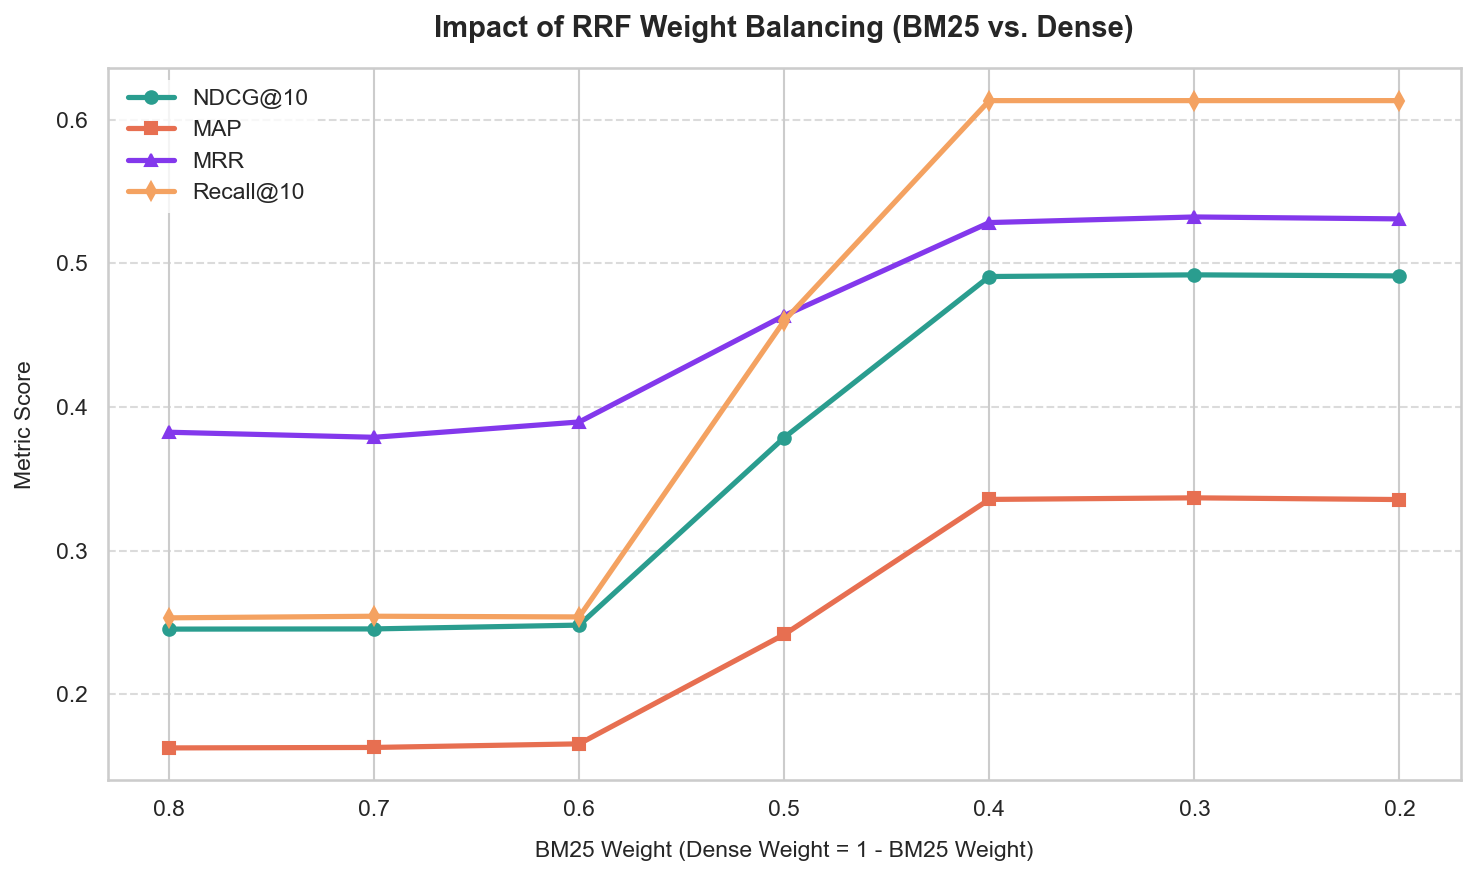

In [13]:
weights = [[0.8, 0.2], [0.7, 0.3], [0.6, 0.4], [0.5, 0.5], [0.4, 0.6], [0.3, 0.7], [0.2, 0.8]]

# 1. Retrieve candidates pool once to run RRF in-memory extremely fast
print("Caching candidate search results for BM25 and Dense...")
bm25_candidate_runs = []
dense_candidate_runs = []
for i, qrel in enumerate(qrels):
    if (i + 1) % 50 == 0 or i == 0 or i == len(qrels) - 1:
        print(f"  Fetching candidates for query {i+1}/{len(qrels)}...")
    bm25_candidate_runs.append(bm25.search(qrel.query, top_k=settings.hybrid_candidate_pool))
    dense_candidate_runs.append(dense.search(qrel.query, top_k=settings.hybrid_candidate_pool))

from collections import defaultdict
def fuse_rrf(bm25_results, dense_results, w_bm25, w_dense, k=60, top_k=10):
    rrf_scores = defaultdict(float)
    for r in bm25_results:
        rrf_scores[r.isbn13] += w_bm25 * (1.0 / (k + r.rank))
    for r in dense_results:
        rrf_scores[r.isbn13] += w_dense * (1.0 / (k + r.rank))
    sorted_items = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return [isbn for isbn, _ in sorted_items]

results_data = []
print("\nEvaluating weight combinations...")
for w_bm25, w_dense in weights:
    label = f"BM25:{w_bm25:.1f} / Dense:{w_dense:.1f}"
    
    # Run fusion on cached candidates
    fused_results = []
    for bm25_res, dense_res in zip(bm25_candidate_runs, dense_candidate_runs):
        fused_isbns = fuse_rrf(bm25_res, dense_res, w_bm25, w_dense, k=settings.rrf_k, top_k=10)
        fused_results.append(fused_isbns)
        
    # Compute metrics
    p5 = np.mean([precision_at_k(ret, set(qrel.relevant_isbns), k=5) for ret, qrel in zip(fused_results, qrels)])
    p10 = np.mean([precision_at_k(ret, set(qrel.relevant_isbns), k=10) for ret, qrel in zip(fused_results, qrels)])
    r5 = np.mean([recall_at_k(ret, set(qrel.relevant_isbns), k=5) for ret, qrel in zip(fused_results, qrels)])
    r10 = np.mean([recall_at_k(ret, set(qrel.relevant_isbns), k=10) for ret, qrel in zip(fused_results, qrels)])
    mrr_val = np.mean([mrr(ret, set(qrel.relevant_isbns)) for ret, qrel in zip(fused_results, qrels)])
    ndcg10 = np.mean([ndcg_at_k(ret, set(qrel.relevant_isbns), k=10) for ret, qrel in zip(fused_results, qrels)])
    map_val = np.mean([map_score(ret, set(qrel.relevant_isbns)) for ret, qrel in zip(fused_results, qrels)])
    
    results_data.append({
        'Weight Configuration': label,
        'BM25 Weight': w_bm25,
        'Dense Weight': w_dense,
        'P@5': p5,
        'P@10': p10,
        'R@5': r5,
        'R@10': r10,
        'MRR': mrr_val,
        'NDCG@10': ndcg10,
        'MAP': map_val
    })

# Format and display DataFrame
df_results = pd.DataFrame(results_data)
print("=" * 105)
print(f"{'Weight Config':<25} | {'P@5':<8} | {'P@10':<8} | {'R@5':<8} | {'R@10':<8} | {'MRR':<8} | {'NDCG@10':<8} | {'MAP':<8}")
print("=" * 105)
for idx, row in df_results.iterrows():
    print(f"{row['Weight Configuration']:<25} | {row['P@5']:.4f}   | {row['P@10']:.4f}    | {row['R@5']:.4f}   | {row['R@10']:.4f}    | {row['MRR']:.4f}   | {row['NDCG@10']:.4f}     | {row['MAP']:.4f}")
print("=" * 105)

# Matplotlib visualization of metrics with curated color palettes and rich aesthetics
plt.figure(figsize=(10, 6))
plt.plot(df_results['BM25 Weight'], df_results['NDCG@10'], marker='o', linewidth=2.5, color='#2A9D8F', label='NDCG@10')
plt.plot(df_results['BM25 Weight'], df_results['MAP'], marker='s', linewidth=2.5, color='#E76F51', label='MAP')
plt.plot(df_results['BM25 Weight'], df_results['MRR'], marker='^', linewidth=2.5, color='#8338EC', label='MRR')
plt.plot(df_results['BM25 Weight'], df_results['R@10'], marker='d', linewidth=2.5, color='#F4A261', label='Recall@10')

plt.title('Impact of RRF Weight Balancing (BM25 vs. Dense)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('BM25 Weight (Dense Weight = 1 - BM25 Weight)', fontsize=11, labelpad=10)
plt.ylabel('Metric Score', fontsize=11, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().invert_xaxis()
plt.xticks(df_results['BM25 Weight'], [f"{w:.1f}" for w in df_results['BM25 Weight']])
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()
